# Ejercicios de práctica
En el siguiente notebook, se busca resolver de manera simple los desafís propuestos para la clase 2, indicados en el archivo "Ejercicios.md".

## Enunciado
Sos un data scientist que trabaja para una empresa de publicidad que lanzo una campaña de publicidad en una red social. 
Se registró cada usuario al que se le mostró la publicidad, y se pudo obtener datos de la persona tales como `genero`, `edad` y `salario estimado`. Además, se registró si el usuario luego compró el producto que la publicidad hacía referencia. Los datos están en `Social_Network_Ads.csv`. Se busca poder predecir dado un usuario con datos socioeconómicos si va a comprar o no el producto.

## Consigna 1
Realice un estudio de variables y de limpieza de datos. Analice las clases, están balanceadas, o no? ¿Qué clase nos parece más importante de las dos?

In [33]:
# Importar librerías
import pandas as pd

In [34]:
# Cargar el dataset y chusmearlo
df = pd.read_csv("datasets/Social_Network_Ads.csv")
print(f"Shape: {df.shape}")
print(df.head())
print()
print(f"Faltantes: {df.isnull().sum()}")
print()
print(df.dtypes)
print()
print(df.describe())
print()
print(f"Duplicados: {df.duplicated().sum()}")

Shape: (400, 5)
    User ID  Gender   Age  EstimatedSalary  Purchased
0  15624510    Male  19.0          19000.0          0
1  15810944    Male  35.0          20000.0          0
2  15668575  Female  26.0          43000.0          0
3  15603246  Female  27.0          57000.0          0
4  15804002    Male  19.0          76000.0          0

Faltantes: User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

User ID              int64
Gender              object
Age                float64
EstimatedSalary    float64
Purchased            int64
dtype: object

            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.5694

In [35]:
print(df.isnull().sum())
print(df.isna().sum())


User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [36]:
import matplotlib.pyplot as plt

In [37]:
# mean = df.mean()
# std = df.std()

C:\Users\gabriel.quiroga\AppData\Local\Temp\ipykernel_40200\454877287.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
C:\Users\gabriel.quiroga\AppData\Local\Temp\ipykernel_40200\454877287.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


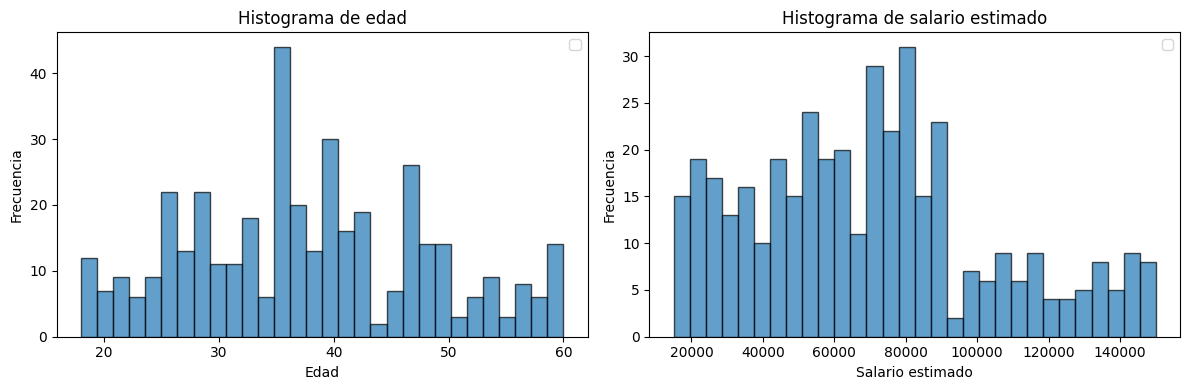

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df['Age'], bins=30, edgecolor='black', alpha=0.7)
ax[0].set_xlabel('Edad')
ax[0].set_ylabel('Frecuencia')
ax[0].set_title('Histograma de edad')
ax[0].legend()

ax[1].hist(df['EstimatedSalary'], bins=30, edgecolor='black', alpha=0.7)
ax[1].set_xlabel('Salario estimado')
ax[1].set_ylabel('Frecuencia')
ax[1].set_title('Histograma de salario estimado')
ax[1].legend()

plt.tight_layout()
plt.show()

Balance general:
 Purchased
0    257
1    143
Name: count, dtype: int64
Porcentaje purchased: 35.75%
Porcentaje no purchased: 64.25%


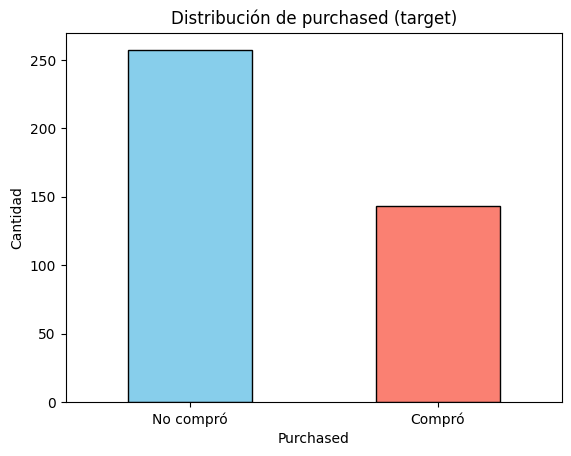

In [39]:
# Analizar balance de clases (Purchased)
target = 'Purchased'
X = df.drop(columns=target)
y = df[target]

conteo_clases = y.value_counts()
# Si querés ver el balance de ambas clases:
print("Balance general:\n", conteo_clases)
y_true = (y==1).sum()
print(f"Porcentaje purchased: {y_true/len(y)*100}%")
y_false = (y==0).sum()
print(f"Porcentaje no purchased: {y_false/len(y)*100}%")

# Plotear target
y.value_counts().plot(kind='bar', color=['skyblue','salmon'], edgecolor='black' )
plt.title("Distribución de purchased (target)")
plt.ylabel('Cantidad')
plt.xticks([0, 1], ['No compró', 'Compró'], rotation=0)
plt.show()

In [40]:
import numpy as np
probs = y.value_counts(normalize=True)
print(f"Entropía de Shannon: {-np.sum(probs * np.log2(probs))}")

Entropía de Shannon: 0.9405884140193839


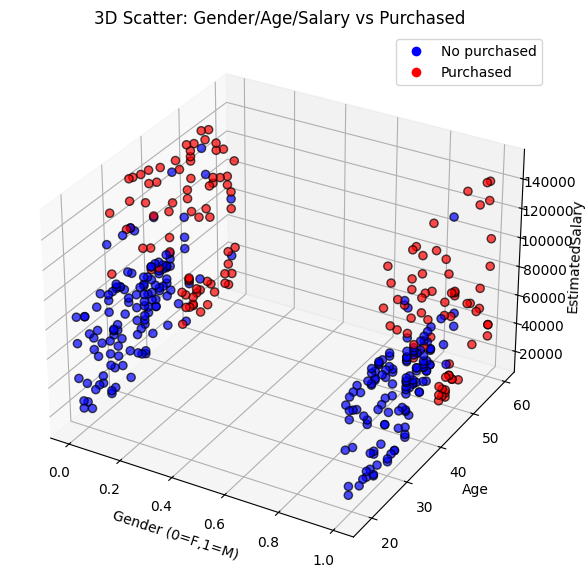

In [41]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

colors = df["Purchased"].map({0: "blue", 1: "red"})
ax.scatter(df["Gender"]=="Male", df["Age"], df["EstimatedSalary"],
           c=colors, s=35, alpha=0.7, edgecolor="k")

ax.set_xlabel("Gender (0=F,1=M)")
ax.set_ylabel("Age")
ax.set_zlabel("EstimatedSalary")
ax.set_title("3D Scatter: Gender/Age/Salary vs Purchased")

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="No purchased", markerfacecolor="blue", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", label="Purchased", markerfacecolor="red", markersize=8)
]
ax.legend(handles=legend_handles)
plt.show()

### Respuesta
El balance entre clases es del 35,75% para los que sí compraron y del 64,25% para los que no. El dataset no parece excesivamente desbalanceado, pero se podrían dropear algunos casos de los que sí compraron para emparejarlo.
La clase que nos parece más importante es la de usuarios que sí compraron, que es la etiqueta minoritaria, por lo cual la métrica que se puede considerar de mayor interés es la Recuperación (Recall).

## Consigna 2
Separe el dataset en entrenamiento y validación.

In [42]:
# Antes de separar, vamos a dropear la column de ID ya que no aporta datos relevantes para los modelos
X = X.drop('User ID', axis=1)
# También se convierte la columna de Gender a un nuevo feature, numérico, tal que ahora 1 = Male y 0 = Female.
# Tipo One Hot Encoding, pero manteniendo solo una columna ya que si Male es True, evidentemente Female
# es False y viceversa. La columna ahora se llama Gender_Male.
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

In [43]:
from sklearn.model_selection import train_test_split

# Usando stratify=y para mantener la proporción entre ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(320, 3)
(80, 3)
(320,)
(80,)


## Consigna 3
Elija diferentes modelos de clasificación (al menos uno de regresión logística y uno de KNN). Elija las variables de entrada basándonos en el análisis del punto 1.

### Regresión Logística

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [45]:
# Para la regresión logística se deben normalizar los atributos preferentemente
# sc = StandardScaler()

cols_to_scale = ['Age', 'EstimatedSalary', 'Gender_Male']

# Lo comento porque en realidad no hace falta escalarlo acá, sino en el Pipeline
# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

# X_train_scaled[cols_to_scale] = sc.fit_transform(X_train[cols_to_scale])
# X_test_scaled[cols_to_scale] = sc.fit_transform(X_test[cols_to_scale])

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_to_scale)
    ]
)

reg_log = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LogisticRegression())
])

reg_log.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [47]:
y_pred = reg_log.predict(X_test)

Text(0.5, 1.0, 'Clasificación mediante Regresión Logística')

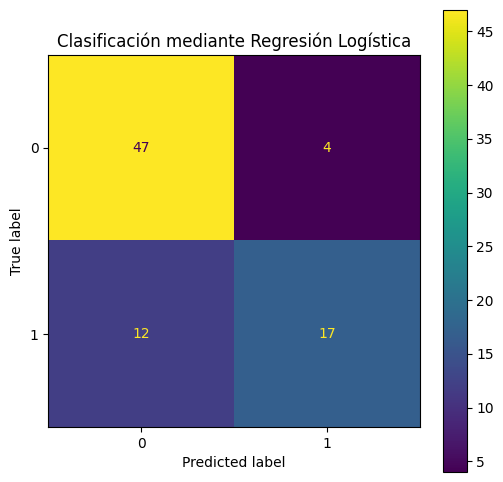

In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

cm_reg_log = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_reg_log,
    display_labels=reg_log.classes_
)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title('Clasificación mediante Regresión Logística')

In [49]:
print("Clasificador Regresión Logística")
P = np.sum(cm_reg_log[1, :])
N = np.sum(cm_reg_log[0, :])
TP = cm_reg_log[1, 1]
TN = cm_reg_log[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0)}")

Clasificador Regresión Logística
Sensibilidad: 0.5862068965517241
Especificidad: 0.9215686274509803
Exactitud balanceada: 0.7538877620013522
Precision: 0.8095238095238095
Recuperación: 0.5862068965517241
F1-score: 0.68


### Clasificador KNN

In [50]:
from sklearn.neighbors import KNeighborsClassifier

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_to_scale)
    ]
)
knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=15, metric="minkowski", p=2))
])

knn.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
y_pred_knn = knn.predict(X_test)

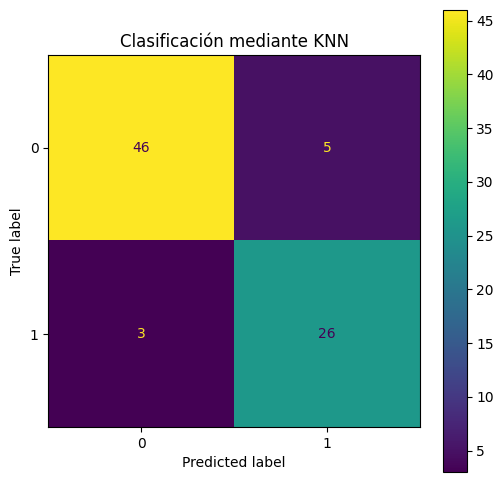

In [53]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=knn.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.grid = False
ax.set_title('Clasificación mediante KNN')
disp_knn.plot(ax=ax)

In [54]:
print("Clasificador KNN")
P = np.sum(cm_knn[1, :])
N = np.sum(cm_knn[0, :])
TP = cm_knn[1, 1]
TN = cm_knn[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred_knn, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred_knn, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred_knn, zero_division=0)}")

Clasificador KNN
Sensibilidad: 0.896551724137931
Especificidad: 0.9019607843137255
Exactitud balanceada: 0.8992562542258282
Precision: 0.8387096774193549
Recuperación: 0.896551724137931
F1-score: 0.8666666666666667


Se eligieron unos hiperparámetros completamente aleatorios para el clasificador, e igualmente se obtuvo una mejora en casi todas las métricas evaluadas, pero principalmente se mejoró el recall que por la naturaleza del problema es la que más nos interesa.

## Consigna 4
Compárelos con dos o más metrica de evaluación. ¿Cuál fue el mejor modelo? ¿Todas las métricas coincidieron o métricas diferentes evaluan como mejor a diferentes modelos? Discuta los resultados.

Para hacer una comparación de las métricas en general, véase la siguiente tabla:

| Métrica | Definición | Regresión Logística | Clasificador KNN |
|---|---|---|---|
| Sensibilidad | Representa la capacidad del clasificador para detectar todos los casos positivos en los datos -> 𝑇𝑃𝑅 = 𝑇𝑃 / (TP + FN) | 0.586 | 0.897 |
| Especificidad | Indica la capacidad del clasificador para identificar correctamente los casos negativos -> 𝑇𝑁𝑅 = 𝑇𝑁 / (𝑇𝑁 + FP) | 0.921 | 0.902 |
| Exactitud balanceada | Representa la tasa de aciertos teniendo en cuenta el desbalance de clases -> (TPR + TNR) / 2 | 0.754 | 0.899 |
| Precisión | Se refiere a la proporción de casos positivos identificados correctamente por el clasificador con respecto a todos los casos que el clasificador etiquetó como positivos -> 𝑃𝑟𝑒𝑐𝑖𝑠𝑖𝑜𝑛 = 𝑇𝑃 / (𝑇𝑃 + FP) | 0.809 | 0.839 |
| Recuperación | Mide la proporción de casos positivos que el clasificador identificó correctamente con respecto a todos los casos positivos reales en los datos. En otras palabras, la recuperación indica la capacidad del clasificador para "recuperar" los casos positivos -> 𝑅𝑒𝑐𝑎𝑙𝑙 = TP / (𝑇𝑃 + FN) | 0.586 | 0.897 |
| F1-Score | La puntuación F1 es la media armónica de la precisión y la recuperación -> F1 = 2 * (Precision * Recall) / (Precision + Recall) | 0.680 | 0.867 |

Esto evidencia cómo el clasificador KNN tiene un desempeño mejor en general respecto al modelo de regresión logística.

## Consigna 5
Para la regresión logística, cree una curva ROC para evaluar el modelo para ver la calidad del modelo, sin depender del valor umbral. Elija un valor umbral que considere óptimo y vuelva a clasificar usando ese valor. ¿Cómo cambiaron las métricas usadas en el punto 4 con este valor umbral?

array([       inf, 0.99405664, 0.97869491, 0.97569969, 0.74734329,
       0.71407669, 0.7085981 , 0.5994807 , 0.53786716, 0.52264221,
       0.47776019, 0.47106462, 0.44000838, 0.40073161, 0.39827237,
       0.35626051, 0.35230572, 0.34828348, 0.31254983, 0.28632278,
       0.26667787, 0.2444104 , 0.23625044, 0.23596443, 0.20083363,
       0.01884778, 0.012329  , 0.00381215])

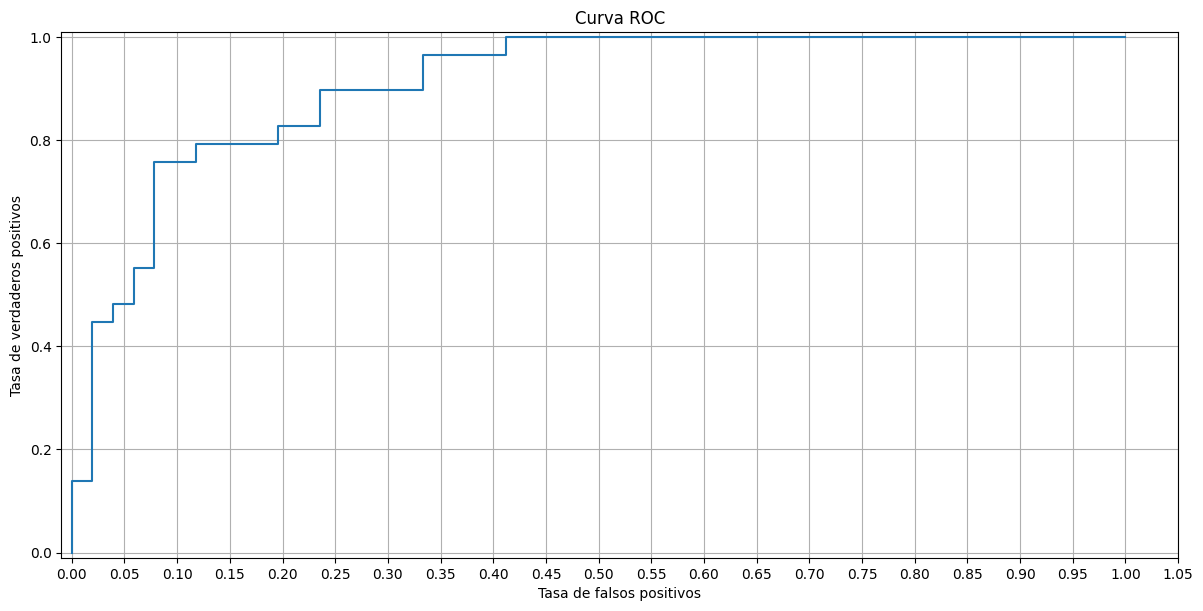

In [55]:
from sklearn.metrics import roc_curve

p_pred = reg_log.predict_proba(X_test)

fpr, tpr, thr = roc_curve(y_test, p_pred[:, 1]) # Returns False positive rate, true positive rate and thresholds

plt.figure(figsize=(12,6))
plt.plot(fpr, tpr)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.tight_layout()
plt.title("Curva ROC")
plt.grid()
plt.xticks(np.arange(0.0, 1.1, step=0.05))
thr

Para superar el Recall obtenido con el clasificador KNN, fijaremos un objetivo de 0.90 y obtener el umbral correspondiente. Luego, volver a clasificar con este "nuevo modelo" y observar las métricas en general.

In [56]:
target_recall = 0.90
idx = np.where(tpr >= target_recall)[0][0]

umbral_elegido = thr[idx]
fpr_resultante = fpr[idx]

print(umbral_elegido)

0.2666778713279407


Usando el umbral 0.266677871 ~= 0.27, tenemos los siguientes resultados.

In [57]:
p_pred_purchased = p_pred[:, 1]

y_pred_nuevo_umbral = (p_pred_purchased >= umbral_elegido).astype(int)

Text(0.5, 1.0, 'Calsificación mediante Regresión Logística, con umbral en ~0.27')

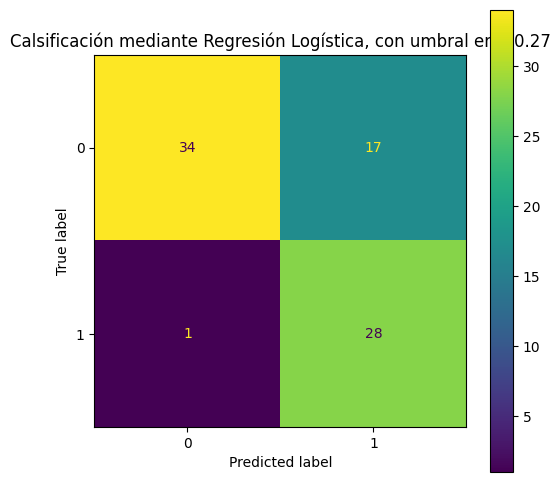

In [58]:
cm_reg_log_nuevo_umbral = confusion_matrix(y_test, y_pred_nuevo_umbral)

disp_nuevo_umbral = ConfusionMatrixDisplay(
    confusion_matrix = cm_reg_log_nuevo_umbral,
    display_labels=reg_log.classes_
)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp_nuevo_umbral.plot(ax=ax)
ax.set_title('Calsificación mediante Regresión Logística, con umbral en ~0.27')

In [59]:
print("Clasificador Regresión Logística con umbral en 0.27")
P = np.sum(cm_reg_log_nuevo_umbral[1, :])
N = np.sum(cm_reg_log_nuevo_umbral[0, :])
TP = cm_reg_log_nuevo_umbral[1, 1]
TN = cm_reg_log_nuevo_umbral[0, 0]
TPR = TP / P
TNR = TN / N

print(f"Sensibilidad: {TPR}")
print(f"Especificidad: {TNR}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precisión: {precision_score(y_test, y_pred_nuevo_umbral, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred_nuevo_umbral, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred_nuevo_umbral, zero_division=0)}")

Clasificador Regresión Logística con umbral en 0.27
Sensibilidad: 0.9655172413793104
Especificidad: 0.6666666666666666
Exactitud balanceada: 0.8160919540229885
Precisión: 0.6222222222222222
Recuperación: 0.9655172413793104
F1-score: 0.7567567567567568


Haciendo una nueva comparativa de las métricas obtenidadas:

| Métrica | Regresión Logística | Clasificador KNN | RL (umbral=0.27)
|---|---|---|---|
| Sensibilidad | 0.586 | 0.897 | 0.966 |
| Especificidad | 0.921 | 0.902 | 0.667 |
| Exactitud balanceada | 0.754 | 0.899 | 0.816 |
| Precisión | 0.809 | 0.839 | 0.622 |
| Recuperación | 0.586 | 0.897 | 0.966 |
| F1-Score | 0.680 | 0.867 | 0.757 |

Se puede ver que cambiando el umbral de la manera que lo hicimos, se aumenta significativamente la métrica de recall, que era nuestro objetivo justamente.

## Consigna 6
Utilizando alguna técnica de busqueda de hiper-parámetros, busque para el clasificador kNN los mejores parámetros. Se recomienda usar `n_neighbors`, `weights` y 'p', dejando el parámetro de distancia fijo como `'minkowski'`.

In [60]:
# Se vuelve a iniciar el proceso para poder obtener los datos escalados
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Vamos a aplicar la optimización bayesiana para encontrar los hiperparámetros que maximicen el recall, siguiendo con el objetivo de la sección anterior.
El modelo probabilístico elegido es un Proceso Gaussiano y la función de adquisición será la Mejora Esperada (o Expected Improvement) que ofrece un buen equilibrio entre exploración y explotación.

La búsqueda va evaluando puntos elegidos primero aleatoriamente y después mediante la función de adquisición, mientras va ajustando y completando el modelo probabilístico con cada evaluación de un punto.

In [61]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [62]:
# Definimos funciones para nuestra búsqueda

def knn_score(params):
    """
    Calcula el recall promedio del clasificadorr KNN con diferentes hiperparámetros.
    Input:
    - params: diccionario con los hiperparámetros a evaluar.

    Output:
    - Valor promedio del recall obtenido con esos hiperparámetros, usando validación cruzada.
    """
    model = KNeighborsClassifier(
        n_neighbors=int(params['K']),
        metric="minkowski",
        p=float(params['p'])
        
    )
    return np.mean(
        cross_val_score(
            model,
            X_train_sc,
            y_train,
            cv=5,
            scoring='recall'
        )
    )

kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=1.0,
    length_scale_bounds=(1e-2, 1e2),
    nu=2.5
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10, # Evitar óptimos locales
    random_state=42,
    alpha=1e-6,
    normalize_y=True
)

def expected_improvement(x_candidatos, gp, mejor_actual, xi=0.01):
    """
    Calcula la Mejora Esperada (EI).
    
    x_candidato: El hiperparámetro a evaluar (ej: array con un valor [k])
    gp: El modelo GaussianProcessRegressor ya entrenado (con .fit)
    mejor_score_actual: El mejor accuracy o r2_score encontrado hasta ahora en el KNN
    xi: Pequeño parámetro para forzar exploración
    """
    mu, sigma = gp.predict(x_candidatos, return_std=True)
    mu = mu.ravel()
    sigma = sigma.ravel()
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - mejor_actual - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0
    return ei

In [63]:
# Parámetros a optimizar
k_values = np.arange(1, 50)         # k entre 1 y 49
p_values = [
    0.1, 0.2, 0.4, 0.5, 0.7, 1, 2, 4, 7, 10
]

n_init = 5                          # puntos iniciales aleatorios
n_iter = 50                         # iteraciones del algoritmo

In [64]:
evaluated_params = []
evaluated_scores = []

# Generación de puntos inicialies aleatorios
np.random.seed(42)
for _ in range(n_init):
    params = {
        'K': np.random.choice(k_values),
        'p': np.random.choice(p_values)
    }
    score = knn_score(params)
    evaluated_params.append(params)
    evaluated_scores.append(score)

print('Valores iniciales de hiperparámetros')
print(evaluated_params)

print('Scores iniciales')
print(evaluated_scores)

c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_bas

Valores iniciales de hiperparámetros
[{'K': np.int64(39), 'p': np.float64(0.5)}, {'K': np.int64(29), 'p': np.float64(4.0)}, {'K': np.int64(21), 'p': np.float64(2.0)}, {'K': np.int64(19), 'p': np.float64(2.0)}, {'K': np.int64(11), 'p': np.float64(4.0)}]
Scores iniciales
[np.float64(0.4897233201581027), np.float64(0.6225296442687747), np.float64(0.7632411067193676), np.float64(0.7719367588932806), np.float64(0.8774703557312253)]


In [65]:
for i in range(n_iter):
    best_idx = np.argmax(evaluated_scores)
    best_params = evaluated_params[best_idx]

    param_to_change = np.random.choice(['K', 'p'])
    if param_to_change == 'K':
        best_params['K'] = np.random.choice(k_values)
    else:
        best_params['p'] = np.random.choice(p_values)

    new_score = knn_score(best_params)
    evaluated_params.append(best_params)
    evaluated_scores.append(new_score)

    print(f"Iteración {i+1}: Hiperparámetros: {best_params}, Recall: {new_score:.4f}")

Iteración 1: Hiperparámetros: {'K': np.int64(36), 'p': np.float64(4.0)}, Recall: 0.5439
Iteración 2: Hiperparámetros: {'K': np.int64(36), 'p': np.float64(4.0)}, Recall: 0.5439
Iteración 3: Hiperparámetros: {'K': np.int64(22), 'p': np.float64(4.0)}, Recall: 0.7111


Iteración 4: Hiperparámetros: {'K': np.int64(2), 'p': np.float64(4.0)}, Recall: 0.7087
Iteración 5: Hiperparámetros: {'K': np.int64(2), 'p': np.float64(1.0)}, Recall: 0.7087


c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_bas

Iteración 6: Hiperparámetros: {'K': np.int64(2), 'p': np.float64(0.7)}, Recall: 0.7091
Iteración 7: Hiperparámetros: {'K': np.int64(12), 'p': np.float64(0.7)}, Recall: 0.8510
Iteración 8: Hiperparámetros: {'K': np.int64(12), 'p': np.float64(1.0)}, Recall: 0.8510
Iteración 9: Hiperparámetros: {'K': np.int64(44), 'p': np.float64(1.0)}, Recall: 0.4553
Iteración 10: Hiperparámetros: {'K': np.int64(49), 'p': np.float64(1.0)}, Recall: 0.4379
Iteración 11: Hiperparámetros: {'K': np.int64(42), 'p': np.float64(1.0)}, Recall: 0.4727
Iteración 12: Hiperparámetros: {'K': np.int64(42), 'p': np.float64(0.4)}, Recall: 0.3498


c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_bas

Iteración 13: Hiperparámetros: {'K': np.int64(42), 'p': np.float64(2.0)}, Recall: 0.4818
Iteración 14: Hiperparámetros: {'K': np.int64(42), 'p': np.float64(7.0)}, Recall: 0.4206
Iteración 15: Hiperparámetros: {'K': np.int64(37), 'p': np.float64(7.0)}, Recall: 0.5443
Iteración 16: Hiperparámetros: {'K': np.int64(7), 'p': np.float64(7.0)}, Recall: 0.8949
Iteración 17: Hiperparámetros: {'K': np.int64(9), 'p': np.float64(7.0)}, Recall: 0.8949
Iteración 18: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(7.0)}, Recall: 0.7632
Iteración 19: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(7.0)}, Recall: 0.7632
Iteración 20: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(0.2)}, Recall: 0.6660
Iteración 21: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(7.0)}, Recall: 0.7632
Iteración 22: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(0.7)}, Recall: 0.7368


c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_bas

Iteración 23: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(0.5)}, Recall: 0.7364
Iteración 24: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(2.0)}, Recall: 0.7542
Iteración 25: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(4.0)}, Recall: 0.7719
Iteración 26: Hiperparámetros: {'K': np.int64(35), 'p': np.float64(4.0)}, Recall: 0.5439
Iteración 27: Hiperparámetros: {'K': np.int64(35), 'p': np.float64(0.1)}, Recall: 0.4992
Iteración 28: Hiperparámetros: {'K': np.int64(35), 'p': np.float64(0.2)}, Recall: 0.5423
Iteración 29: Hiperparámetros: {'K': np.int64(35), 'p': np.float64(0.5)}, Recall: 0.5862


c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_bas

Iteración 30: Hiperparámetros: {'K': np.int64(35), 'p': np.float64(1.0)}, Recall: 0.5605
Iteración 31: Hiperparámetros: {'K': np.int64(35), 'p': np.float64(10.0)}, Recall: 0.5530
Iteración 32: Hiperparámetros: {'K': np.int64(35), 'p': np.float64(1.0)}, Recall: 0.5605
Iteración 33: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(1.0)}, Recall: 0.7636
Iteración 34: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(0.2)}, Recall: 0.6660


c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_bas

Iteración 35: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(0.5)}, Recall: 0.7364
Iteración 36: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(4.0)}, Recall: 0.7719
Iteración 37: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(2.0)}, Recall: 0.7542
Iteración 38: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(7.0)}, Recall: 0.7632
Iteración 39: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(4.0)}, Recall: 0.7719
Iteración 40: Hiperparámetros: {'K': np.int64(16), 'p': np.float64(4.0)}, Recall: 0.7814
Iteración 41: Hiperparámetros: {'K': np.int64(18), 'p': np.float64(4.0)}, Recall: 0.7719
Iteración 42: Hiperparámetros: {'K': np.int64(24), 'p': np.float64(4.0)}, Recall: 0.6846
Iteración 43: Hiperparámetros: {'K': np.int64(24), 'p': np.float64(7.0)}, Recall: 0.6759
Iteración 44: Hiperparámetros: {'K': np.int64(24), 'p': np.float64(7.0)}, Recall: 0.6759
Iteración 45: Hiperparámetros: {'K': np.int64(15), 'p': np.float64(7.0)}, Recall: 0.8075
Iteración 46: Hiperpa

In [66]:
# Se obtienen los mejores hiperparámetros entre las iteraciones
best_idx_final = np.argmax(evaluated_scores)
best_params_final = evaluated_params[best_idx_final]

print(f"Mejor combinación de hiperparámetros: K = {int(best_params_final['K'])}, p = {float(best_params_final['p'])}, con recall = {evaluated_scores[best_idx_final]:.4f}")

Mejor combinación de hiperparámetros: K = 44, p = 4.0, con recall = 0.8949


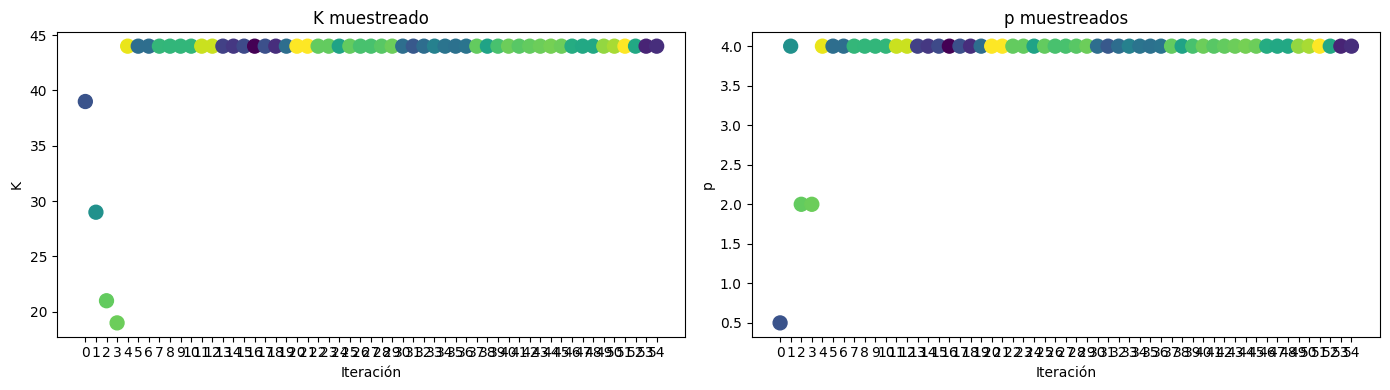

In [67]:
Ks = [param['K'] for param in evaluated_params]
ps = [param['p'] for param in evaluated_params]

plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
plt.scatter(range(len(Ks)), Ks, c=evaluated_scores, cmap='viridis', s=100)
plt.xticks(range(len(Ks)))
plt.xlabel("Iteración")
plt.ylabel("K")
plt.title("K muestreado")

plt.subplot(1,2,2)
plt.scatter(range(len(ps)), ps, c=evaluated_scores, cmap='viridis', s=100)
plt.xticks(range(len(Ks)))
plt.xlabel("Iteración")
plt.ylabel("p")
plt.title("p muestreados")

plt.tight_layout()
plt.show()


Se obtienen varias combinaciones distintas de hiperparámetros que llegan a un recall máximo de 0.8949. Veámos cómo resultan las demás métricas y la matriz de confusión.

In [68]:
best_knn = KNeighborsClassifier(
    n_neighbors=int(best_params_final['K']),
    metric="minkowski",
    p=float(best_params_final['p'])
)

best_knn.fit(X_train_sc, y_train)

,n_neighbors,44
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,4.0
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Text(0.5, 1.0, 'Clasificación con KNN optimizado por Búsqueda Bayesiana')

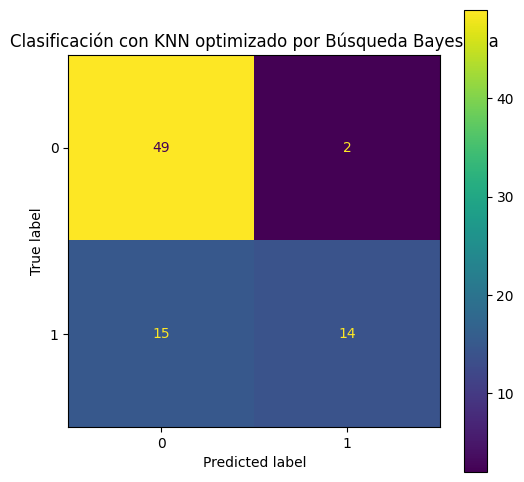

In [69]:
y_pred_best_knn = best_knn.predict(X_test_sc)

cm_best_knn = confusion_matrix(y_test, y_pred_best_knn)

disp_best_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_knn,
    display_labels=best_knn.classes_
)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid = False
disp_best_knn.plot(ax=ax)
ax.set_title('Clasificación con KNN optimizado por Búsqueda Bayesiana')

In [70]:
# Métricas
TN, FP, FN, TP = cm_best_knn.ravel()
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
print(f"Sensibilidad: {TPR}")
print(f"Especificidad: {TNR}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precisión: {precision_score(y_test, y_pred_best_knn, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred_best_knn, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred_best_knn, zero_division=0)}")

Sensibilidad: 0.4827586206896552
Especificidad: 0.9607843137254902
Exactitud balanceada: 0.7217714672075727
Precisión: 0.875
Recuperación: 0.4827586206896552
F1-score: 0.6222222222222222


### Bonus
Voy a probar el desempeño de la Búsqueda Bayesiana usando directamente la clase que ofrece scikit optimize.

In [85]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical


opt = BayesSearchCV(
    KNeighborsClassifier(),
    {
        'n_neighbors': Integer(1,50),
        'p': Real(0.1, 15.0),
        'metric': Categorical(['minkowski'])
    },
    n_iter=32,
    random_state=0,
    scoring='recall'
)

_ = opt.fit(X_train_sc, y_train)



c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
c:\CEIA\AMq1\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\neighbors\_bas

In [86]:
opt.best_params_

OrderedDict([('metric', 'minkowski'),
             ('n_neighbors', 9),
             ('p', 12.615291512266822)])

In [87]:
bonus_knn = KNeighborsClassifier(
    n_neighbors=int(opt.best_params_['n_neighbors']),
    metric="minkowski",
    p=float(opt.best_params_['p'])
)
bonus_knn.fit(X_train_sc, y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,12.615291512266822
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Text(0.5, 1.0, 'Clasificación KNN optimizada por BayesSearchCV')

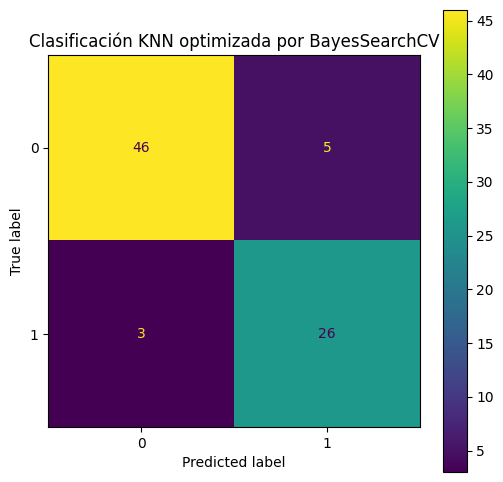

In [88]:
y_pred_bonus_knn = bonus_knn.predict(X_test_sc)

cm_bonus_knn = confusion_matrix(y_test, y_pred_bonus_knn)

disp_bonus_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_bonus_knn,
    display_labels=bonus_knn.classes_
)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid = False
disp_bonus_knn.plot(ax=ax)
ax.set_title('Clasificación KNN optimizada por BayesSearchCV')

In [89]:
# Métricas
TN, FP, FN, TP = cm_bonus_knn.ravel()
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
print(f"Sensibilidad: {TPR}")
print(f"Especificidad: {TNR}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precisión: {precision_score(y_test, y_pred_bonus_knn, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred_bonus_knn, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred_bonus_knn, zero_division=0)}")

Sensibilidad: 0.896551724137931
Especificidad: 0.9019607843137255
Exactitud balanceada: 0.8992562542258282
Precisión: 0.8387096774193549
Recuperación: 0.896551724137931
F1-score: 0.8666666666666667


Observemos la comparación final de los cuatro modelos generados.

| Métrica | Regresión Logística | Clasificador KNN | RL (umbral=0.27) | KNN Bayes Search |
|---|---|---|---|---|
| Sensibilidad | 0.586 | 0.897 | 0.966 | 0.897 |
| Especificidad | 0.921 | 0.902 | 0.667 | 0.902 |
| Exactitud balanceada | 0.754 | 0.899 | 0.816 | 0.899 |
| Precisión | 0.809 | 0.839 | 0.622 | 0.839 |
| Recuperación | 0.586 | 0.897 | 0.966 | 0.897 |
| F1-Score | 0.680 | 0.867 | 0.757 | 0.867 |

Se puede ver que no cambió el desempeño entre las dos versiones de optimización bayesiana.